# EXPLORING AND ANALYZING DATA NOTEBOOK (EDA)

## Library import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data and First Looking

In [5]:
train=pd.read_csv('../data/raw/train.csv')
test=pd.read_csv('../data/raw/test.csv')

In [6]:
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (24153, 58)
Test: (4750, 56)


In [57]:
print("Train columns:", train.shape[1])
print("Test columns:", test.shape[1])

# Test'te olmayan kolonlar
train_cols=set(train.columns)
test_cols=set(test.columns)

print("\nColumns in train but not in test:")
print(train_cols - test_cols)

Train columns: 59
Test columns: 56

Columns in train but not in test:
{'price', 'Unnamed: 0.1', 'host_response_rate_numeric'}


In [9]:
train.head()

,Unnamed: 0.1,Unnamed: 0,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,0,0,25436,https://www.airbnb.com/rooms/25436,20250627144659,2025-06-28,previous scrape,In the forest Sea view Two minutes to the city.,Our house is in Baby Koru. If you want village...,Clean and elegand friends . U can find everyth...,...,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0
1,1,1,34177,https://www.airbnb.com/rooms/34177,20250627144659,2025-07-01,city scrape,PETIT HOUSE,My petit house is located in the bosphorous an...,the neighbourhood is very calm comparing the...,...,4.88,4.81,4.69,4.81,NaN,f,5,5,0,0
2,2,2,42835,https://www.airbnb.com/rooms/42835,20250627144659,2025-06-28,previous scrape,Cozy apartment in the heart of Istanbul,Welcome to our cozy 2-bedroom apartment locate...,NaN,...,NaN,NaN,NaN,NaN,NaN,f,3,1,2,0
3,3,3,73477,https://www.airbnb.com/rooms/73477,20250627144659,2025-07-01,city scrape,Sea View Apartment in Taksim/ Center of Istanbul,Sea View Apartment in Taksim/ Center of Istanbul,Gumussuyu,...,5.00,5.00,5.00,4.91,NaN,f,2,2,0,0
4,4,4,77292,https://www.airbnb.com/rooms/77292,20250627144659,2025-06-30,previous scrape,3 Bedroom Apartment with Terrace Bosphorus View,Who doesn't want to stay in a quiet place that...,"Gümüssuyu 3+1 Apartment with Terrace, offers y...",...,4.86,4.71,4.64,4.21,34-554,f,13,10,3,0


In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24153 entries, 0 to 24152
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0.1                                  24153 non-null  int64  
 1   Unnamed: 0                                    24153 non-null  int64  
 2   id                                            24153 non-null  int64  
 3   listing_url                                   24153 non-null  object 
 4   scrape_id                                     24153 non-null  int64  
 5   last_scraped                                  24153 non-null  object 
 6   source                                        24153 non-null  object 
 7   name                                          24153 non-null  object 
 8   description                                   23501 non-null  object 
 9   neighborhood_overview                         6905 non-null  

### missing value analysis

In [14]:
#null kontrolü %kaçı eksik
missing_pct=(train.isnull().sum() / len(train) * 100)
missing_pct=missing_pct[missing_pct > 0].sort_values(ascending=False)

print(missing_pct)

neighbourhood_group_cleansed    100.000000
host_neighbourhood               89.198029
neighbourhood                    71.411419
neighborhood_overview            71.411419
host_about                       61.263611
license                          47.352296
review_scores_value              37.693040
review_scores_accuracy           37.688900
review_scores_location           37.688900
review_scores_checkin            37.688900
review_scores_communication      37.680619
review_scores_cleanliness        37.680619
review_scores_rating             37.680619
host_location                    36.409556
host_response_time               33.892270
host_response_rate               33.892270
host_acceptance_rate             29.838943
price                            13.865772
bathrooms                        13.720863
beds                             13.588374
host_has_profile_pic              2.765702
host_identity_verified            2.765702
host_verifications                2.765702
host_total_

### Target variable analysis(Price)

Price is our target variable. We need to understand its distribution and handle outliers.

In [23]:
# print(train['price'].head(10))
# train['price'] = train['price'].str.replace(',', '').astype(float)

print(f"Count: {train['price'].notna().sum()}")
print(f"Mean: {train['price'].mean():,.2f}")
print(f"Median: {train['price'].median():,.2f}")
print(f"Min: {train['price'].min():,.2f}")
print(f"Max: {train['price'].max():,.2f}")
print(f"Skewness: {train['price'].skew():.2f}")

Count: 20804
Mean: 4,523.77
Median: 2,493.00
Min: 80.00
Max: 4,250,147.00
Skewness: 78.66


### Price Distribution

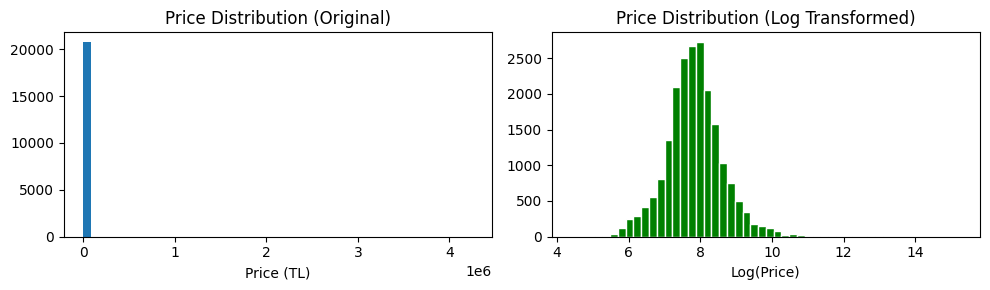

In [34]:
fig,axes=plt.subplots(1, 2, figsize=(10, 3))

# Original
axes[0].hist(train['price'].dropna(), bins=50)
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (TL)')

# Log transformed
axes[1].hist(np.log1p(train['price'].dropna()), bins=50, color='green',edgecolor='white')
axes[1].set_title('Price Distribution (Log Transformed)')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()

### Price Percentiles

Checking percentiles to understand outliers better.

In [35]:
percentiles = [25, 50, 75, 90, 95, 99, 99.5, 99.9]
print("Price Percentiles:\n")
for p in percentiles:
    val = train['price'].quantile(p/100)
    print(f"{p}th: {val:,.0f} TL")

Price Percentiles:

25th: 1,581 TL
50th: 2,493 TL
75th: 3,956 TL
90th: 6,556 TL
95th: 9,726 TL
99th: 25,000 TL
99.5th: 41,863 TL
99.9th: 239,304 TL


## Categorical feature analysis

In [44]:
                #ROOM_TYPE
print(train['room_type'].value_counts())

print("\n\nMean Price by Room Type:\n")
print(train.groupby('room_type')['price'].mean().sort_values(ascending=False).round(0))

room_type
Entire home/apt    16571
Private room        7340
Hotel room           131
Shared room          111
Name: count, dtype: int64


Mean Price by Room Type:

room_type
Entire home/apt    5155.0
Private room       2892.0
Hotel room         2465.0
Shared room        1948.0
Name: price, dtype: float64


In [53]:
            #PROPERTY_TYPE
print("Top 15 Property Types:\n")
print(train['property_type'].value_counts().head(15))

print("\n\nMean Price by Top 10 Property Types:\n")
top_properties = train['property_type'].value_counts().head(10).index
print(train[train['property_type'].isin(top_properties)].groupby('property_type')['price'].mean().sort_values(ascending=False).round(0))

Top 15 Property Types:

property_type
Entire rental unit                    12399
Room in hotel                          2786
Private room in rental unit            2374
Entire home                            1206
Entire condo                            963
Entire serviced apartment               952
Room in boutique hotel                  642
Room in aparthotel                      535
Private room in bed and breakfast       520
Private room in home                    384
Private room in condo                   195
Entire villa                            132
Entire loft                             120
Private room in serviced apartment       84
Shared room in hotel                     67
Name: count, dtype: int64


Mean Price by Top 10 Property Types:

property_type
Room in aparthotel                   9629.0
Entire serviced apartment            7571.0
Entire home                          6030.0
Entire rental unit                   4492.0
Entire condo                         4238.0
Ro

In [40]:
                #NEIGHBOURHOOD
print("Top 15 Neighbourhoods by Count:\n")
print(train['neighbourhood_cleansed'].value_counts().head(15))

print("\n\nTop 15 Neighbourhoods by Mean Price:\n")
print(train.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(15).round(0))

Top 15 Neighbourhoods by Count:

neighbourhood_cleansed
Beyoglu         6687
Fatih           3255
Sisli           3182
Kadikoy         1771
Besiktas        1274
Esenyurt         850
Bahcelievler     687
Uskudar          592
Kagithane        581
Atasehir         467
Bagcilar         436
Sile             368
Maltepe          291
Kucukcekmece     268
Basaksehir       266
Name: count, dtype: int64


Top 15 Neighbourhoods by Mean Price:

neighbourhood_cleansed
Sariyer          33510.0
Sancaktepe       26255.0
Avcilar          15471.0
Gaziosmanpasa    12326.0
Silivri          11015.0
Bagcilar          8527.0
Buyukcekmece      8393.0
Beykoz            7245.0
Sile              7119.0
Catalca           6963.0
Besiktas          6443.0
Adalar            5408.0
Beyoglu           4546.0
Basaksehir        4474.0
Sisli             4450.0
Name: price, dtype: float64


In [54]:
# Host is superhost
print("Superhost Distribution:\n")
print(train['host_is_superhost'].value_counts())

print("\n\nMean Price by Superhost Status:\n")
print(train.groupby('host_is_superhost')['price'].mean().round(0))

Superhost Distribution:

host_is_superhost
f    18506
t     5167
Name: count, dtype: int64


Mean Price by Superhost Status:

host_is_superhost
f    4680.0
t    4059.0
Name: price, dtype: float64


In [55]:
# Host response rate
train['host_response_rate_numeric'] = train['host_response_rate'].str.rstrip('%').astype(float)

print("Host Response Rate Statistics:\n")
print(train['host_response_rate_numeric'].describe())

Host Response Rate Statistics:

count    15967.000000
mean        90.745350
std         25.157936
min          0.000000
25%         99.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate_numeric, dtype: float64


### Numeric Features and Correlation Analysis

Checking correlations between numeric features and price

In [41]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
correlations = train[numeric_cols].corr()['price'].sort_values(ascending=False)

print("Correlations with Price:\n")
print(correlations)

Correlations with Price:

price                                           1.000000
accommodates                                    0.076415
bedrooms                                        0.047440
beds                                            0.046343
bathrooms                                       0.045685
minimum_nights                                  0.025456
latitude                                        0.025223
maximum_nights                                  0.020003
review_scores_value                             0.005660
review_scores_checkin                           0.005424
review_scores_rating                            0.005096
review_scores_accuracy                          0.004662
review_scores_cleanliness                       0.003678
review_scores_location                          0.002797
longitude                                      -0.000787
review_scores_communication                    -0.001216
host_total_listings_count                      -0.003466
calcu

### Accommodates vs Price

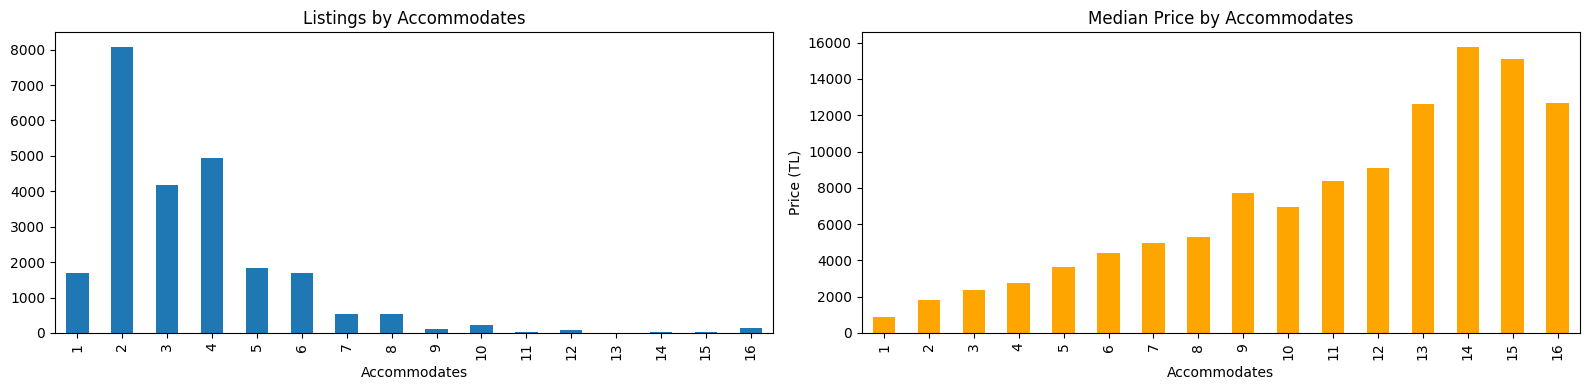

In [50]:
fig,axes = plt.subplots(1,2,figsize=(16, 4))

train['accommodates'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Listings by Accommodates')
axes[0].set_xlabel('Accommodates')

# Median price
train.groupby('accommodates')['price'].median().plot(kind='bar',ax=axes[1],color='orange')
axes[1].set_title('Median Price by Accommodates')
axes[1].set_xlabel('Accommodates')
axes[1].set_ylabel('Price (TL)')

plt.tight_layout()
plt.show()

### Geospatial Analysis

Visualize listing on İstanbul map with price distribution

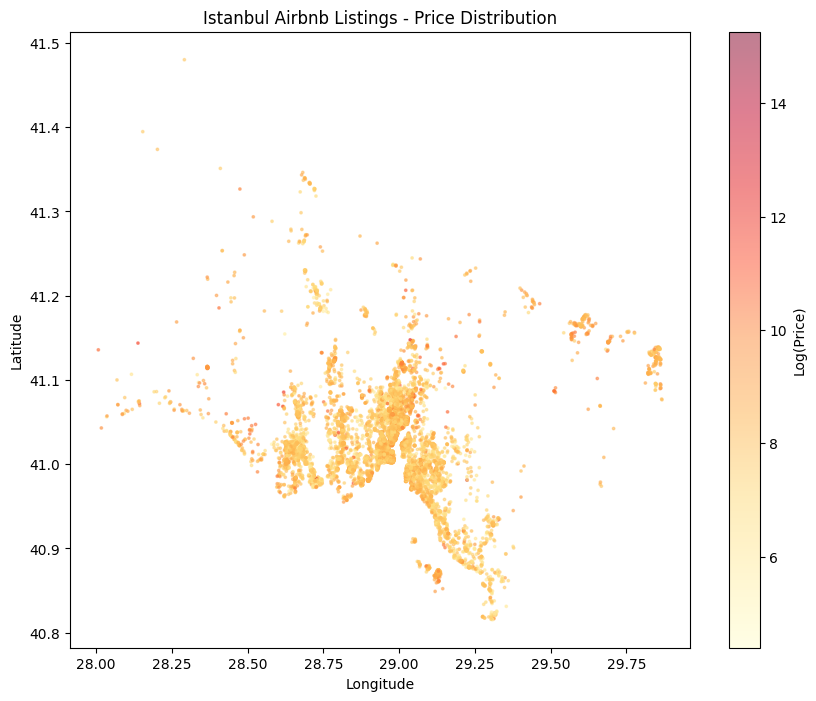

In [43]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(train['longitude'], train['latitude'], 
                      c=np.log1p(train['price']), cmap='YlOrRd', 
                      alpha=0.5, s=3)
plt.colorbar(scatter, label='Log(Price)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Istanbul Airbnb Listings - Price Distribution')
plt.show()

## 7. Key Findings (EDA Summary)

| Finding | Detail |
|---------|--------|
| **Dataset Size** | 24,153 train / 4,750 test samples, 58 features |
| **Missing Values** | 5 columns with >60% missing (will be dropped) |
| **Price Distribution** | Highly skewed (skewness: 78.66), log transform needed |
| **Outliers** | Max price 4.25M TL, but 99% of data is below 25K TL |
| **Room Type** | Entire home/apt is most common (69%) and most expensive |
| **Location** | Beyoğlu, Fatih, Şişli have most listings; Sarıyer has highest prices |
| **Correlations** | Low linear correlations → non-linear models recommended |
